# HAR Model and Rough Volatility

**Docker image**: `ml4t`

This notebook covers multi-horizon volatility modeling and the Hurst exponent
as features for ML trading systems.

**Learning Objectives**:
- Compute true realized volatility from intraday minute-bar returns
- Use range-based estimators (Parkinson, Garman-Klass) as a daily-data fallback
- Build and estimate the HAR model for multi-horizon vol decomposition
- Implement rescaled range (R/S) analysis and DFA for the Hurst exponent
- Interpret rough volatility ($H \approx 0.1$) vs trending/mean-reverting regimes

**Book Reference**: Chapter 9, Section 9.3 (Volatility Features)

**Prerequisites**: Familiarity with GARCH models (`08_garch_volatility`);
range-based estimators introduced in Chapter 8.

In [1]:
"""HAR Model and Rough Volatility — multi-horizon vol features and Hurst exponent."""

import warnings

warnings.filterwarnings("ignore")

from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display
from ml4t.engineer.features.regime import hurst_exponent
from ml4t.engineer.features.volatility import (
    garman_klass_volatility,
    parkinson_volatility,
    realized_volatility,
    rogers_satchell_volatility,
    yang_zhang_volatility,
)
from scipy import stats

from data import load_etfs, load_nasdaq100_bars

In [2]:
# Production defaults — Papermill injects overrides for CI
START_DATE = "2006-01-01"
END_DATE = "2024-12-31"
INTRADAY_SYMBOL = "AAPL"
MIN_BARS_PER_DAY = 360  # Full trading days (~390 1-min bars)

## Load Data

We use two data sources: **NASDAQ-100 minute bars** (AAPL, 2020–2021) for
true intraday realized volatility, and **SPY daily OHLCV** (2006–2024) for
the longer history needed by the HAR model and range-based fallback estimators.

In [3]:
etf_data = load_etfs()

START = date.fromisoformat(START_DATE)
END = date.fromisoformat(END_DATE)
SYMBOL = "SPY"

spy = (
    etf_data.filter(
        (pl.col("symbol") == SYMBOL) & (pl.col("timestamp") >= START) & (pl.col("timestamp") <= END)
    )
    .sort("timestamp")
    .select(["timestamp", "open", "high", "low", "close", "volume"])
)

print(
    f"SPY OHLCV: {len(spy):,} trading days ({spy['timestamp'].min()} to {spy['timestamp'].max()})"
)

SPY OHLCV: 4,781 trading days (2006-01-03 to 2024-12-31)


# Part 1 — Heterogeneous Autoregressive (HAR) Model

The HAR model (Corsi, 2009) decomposes realized volatility into daily, weekly,
and monthly components, capturing the heterogeneous behavior of market
participants operating at different horizons:

$$RV_{t+1}^{(d)} = c + \beta_d \, RV_t^{(d)} + \beta_w \, RV_t^{(w)} + \beta_m \, RV_t^{(m)} + \varepsilon_{t+1}$$

where $RV^{(d)}$, $RV^{(w)}$, $RV^{(m)}$ are realized volatility averaged over
1, 5, and 22 days respectively.

### Realized Volatility from Intraday Returns

The canonical RV measure is the sum of squared intraday returns. With minute
bars from the NASDAQ-100 case study, we compute **true realized volatility**
rather than relying on daily proxies. This is the standard academic approach
(Andersen and Bollerslev 1998).

$$RV_t = \sum_{i=1}^{M} r_{t,i}^2$$

where $r_{t,i}$ is the $i$-th intraday return on day $t$ and $M$ is the
number of intraday intervals (here: 1-minute bars during regular hours).

In [4]:
# Load minute bars (regular trading hours only: 09:30–16:00)

intraday = (
    load_nasdaq100_bars(
        symbols=[INTRADAY_SYMBOL],
        include_microstructure=True,
        lazy=True,
    )
    .filter((pl.col("time") >= "09:30") & (pl.col("time") < "16:00"))
    .select(["date", "symbol", "time", "vwap", "volume"])
    .collect()
    .sort(["date", "time"])
)

print(f"{INTRADAY_SYMBOL} minute bars: {len(intraday):,} observations")
print(f"Date range: {intraday['date'].min()} to {intraday['date'].max()}")
print(f"Trading days: {intraday['date'].n_unique()}")

AAPL minute bars: 196,950 observations
Date range: 2020-01-02 to 2021-12-31
Trading days: 505


In [5]:
# Compute true realized volatility: sum of squared 1-minute log returns per day
intraday_rv = (
    intraday.with_columns(
        log_ret=pl.col("vwap").log().diff().over("date"),
    )
    .drop_nulls(subset=["log_ret"])
    .group_by("date")
    .agg(
        # Daily RV = sum of squared intraday returns, annualized
        rv_intraday=(pl.col("log_ret").pow(2).sum() * 252).sqrt(),
        n_bars=pl.col("log_ret").count(),
    )
    .sort("date")
    .filter(pl.col("n_bars") >= MIN_BARS_PER_DAY)
)

print(f"Intraday RV computed: {len(intraday_rv):,} trading days")
rv_mean = intraday_rv["rv_intraday"].mean()
print(f"Mean annualized RV: {rv_mean:.4f}" if rv_mean is not None else "No full trading days")

Intraday RV computed: 505 trading days
Mean annualized RV: 0.2146


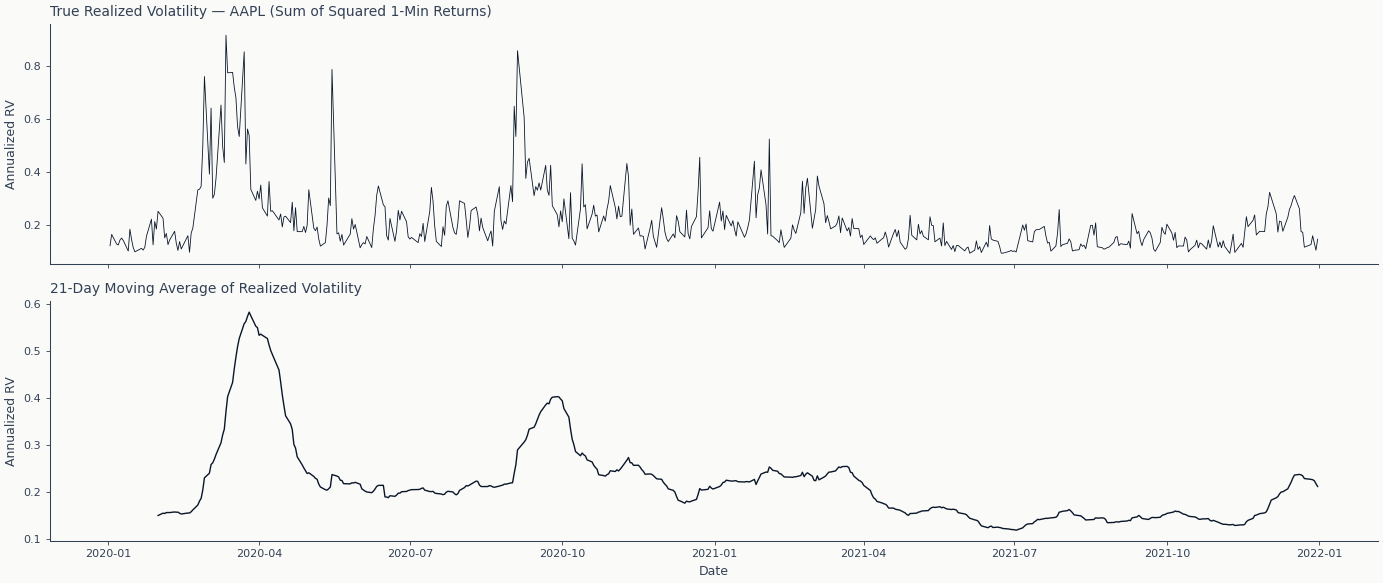

In [6]:
# Visualize intraday RV
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

rv_pd = intraday_rv.to_pandas().set_index("date")

ax = axes[0]
ax.plot(rv_pd.index, rv_pd["rv_intraday"], linewidth=0.6)
ax.set_title(f"True Realized Volatility — {INTRADAY_SYMBOL} (Sum of Squared 1-Min Returns)")
ax.set_ylabel("Annualized RV")

# 21-day moving average for smoother view
ax = axes[1]
rv_smooth = rv_pd["rv_intraday"].rolling(21).mean()
ax.plot(rv_pd.index, rv_smooth, linewidth=1.0)
ax.set_title("21-Day Moving Average of Realized Volatility")
ax.set_ylabel("Annualized RV")
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

The intraday RV series shows the characteristic volatility clustering and
mean-reversion that the HAR model is designed to capture. We use this as
the primary RV input for the HAR demonstration below.

For the HAR model estimation on SPY (which requires a longer history than
the 2020–2021 intraday window), we use range-based estimators as a fallback.

### Fallback: Range-Based Realized Volatility

When intraday data is unavailable — as for longer histories or less liquid
assets — range-based estimators approximate RV from daily OHLC prices.
These extract more variance information than close-to-close returns
alone (Chapter 8, Section 8.2).

In [7]:
def compute_range_rv(df: pl.DataFrame) -> pl.DataFrame:
    """Compute range-based realized volatility estimators from OHLCV data.

    Returns DataFrame with Parkinson, Garman-Klass, and close-to-close RV.
    """
    return df.with_columns(
        # Log returns (close-to-close)
        log_return=pl.col("close").log().diff(),
        # Parkinson (1980): uses high-low range
        # Var = (1 / 4*ln(2)) * (ln(H/L))^2
        rv_parkinson=((pl.col("high") / pl.col("low")).log().pow(2) / (4.0 * np.log(2))).sqrt()
        * np.sqrt(252),
        # Garman-Klass (1980): uses OHLC
        # Var = 0.5 * (ln(H/L))^2 - (2*ln(2) - 1) * (ln(C/O))^2
        rv_garman_klass=(
            0.5 * (pl.col("high") / pl.col("low")).log().pow(2)
            - (2.0 * np.log(2) - 1.0) * (pl.col("close") / pl.col("open")).log().pow(2)
        )
        .clip(lower_bound=0)
        .sqrt()
        * np.sqrt(252),
        # Close-to-close squared return (annualized vol proxy)
        rv_cc=(pl.col("close").log().diff().pow(2)).sqrt() * np.sqrt(252),
    )


spy_rv = compute_range_rv(spy).drop_nulls(subset=["log_return"])
print(f"Range-based RV computed: {len(spy_rv):,} observations")
spy_rv.select(["timestamp", "rv_parkinson", "rv_garman_klass", "rv_cc"]).head(5)

Range-based RV computed: 4,780 observations


timestamp,rv_parkinson,rv_garman_klass,rv_cc
date,f64,f64,f64
2006-01-04,0.05926,0.060838,0.074994
2006-01-05,0.0532,0.060046,0.009979
2006-01-06,0.090889,0.102018,0.131551
2006-01-09,0.050364,0.052869,0.040732
2006-01-10,0.053368,0.049178,0.016019


### Compare Estimator Properties

Parkinson and Garman-Klass are more efficient than close-to-close (they use
intraday range information), producing smoother volatility estimates.

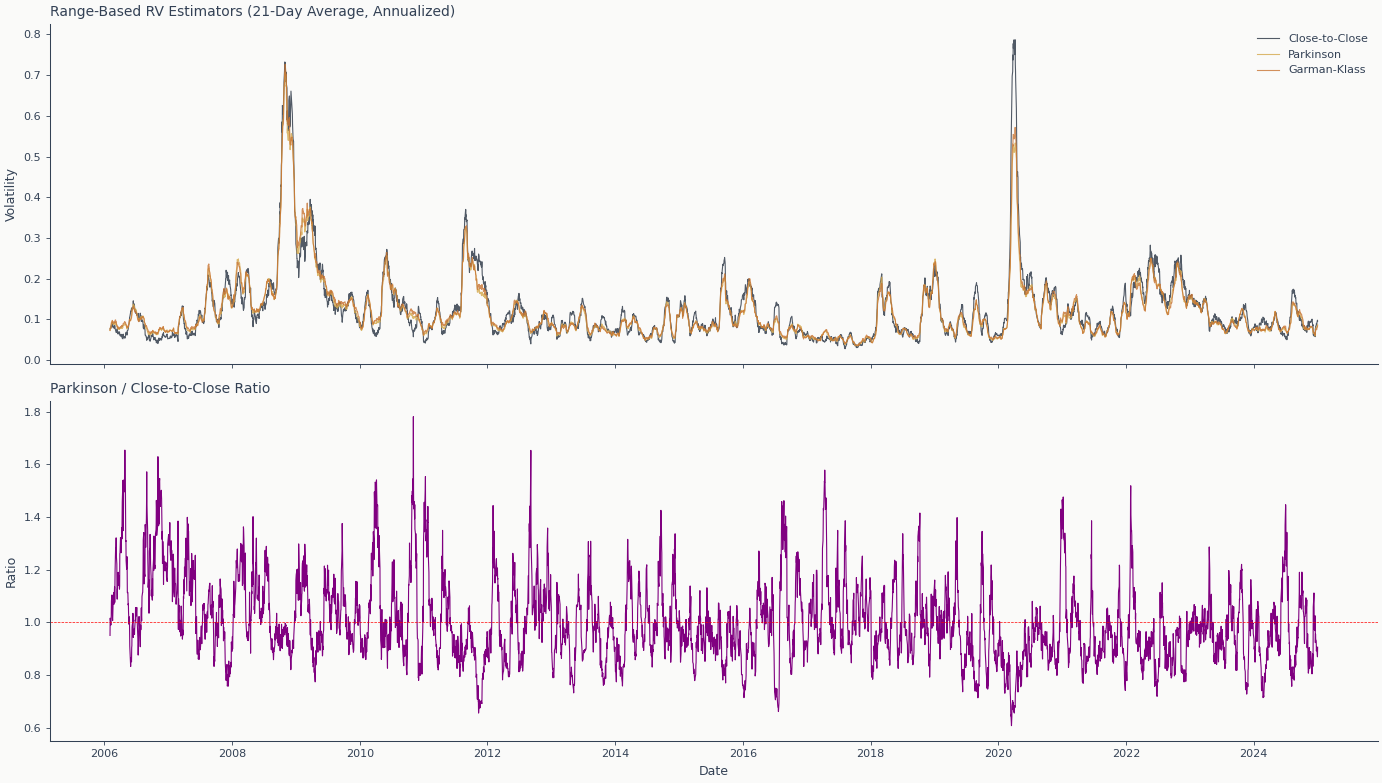

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Convert to pandas for plotting
rv_pd = spy_rv.select(["timestamp", "rv_parkinson", "rv_garman_klass", "rv_cc"]).to_pandas()
rv_pd.set_index("timestamp", inplace=True)

# Rolling 21-day average to smooth daily noise
rv_smooth = rv_pd.rolling(21).mean()

ax = axes[0]
ax.plot(rv_smooth.index, rv_smooth["rv_cc"], label="Close-to-Close", alpha=0.7, linewidth=0.8)
ax.plot(rv_smooth.index, rv_smooth["rv_parkinson"], label="Parkinson", alpha=0.8, linewidth=0.8)
ax.plot(
    rv_smooth.index, rv_smooth["rv_garman_klass"], label="Garman-Klass", alpha=0.8, linewidth=0.8
)
ax.set_title("Range-Based RV Estimators (21-Day Average, Annualized)")
ax.set_ylabel("Volatility")
ax.legend()

# Efficiency ratio: Parkinson vs close-to-close
ax = axes[1]
efficiency = rv_smooth["rv_parkinson"] / rv_smooth["rv_cc"]
ax.plot(rv_smooth.index, efficiency, linewidth=0.8, color="purple")
ax.axhline(1.0, color="red", linestyle="--", linewidth=0.5)
ax.set_title("Parkinson / Close-to-Close Ratio")
ax.set_ylabel("Ratio")
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

### ml4t-engineer: All Five Estimators in One Call

The manual implementation above shows how Parkinson and Garman-Klass work
internally. For production use across many symbols, `ml4t-engineer` provides
all five standard range-based estimators as Polars expressions — including
Rogers-Satchell (drift-independent) and Yang-Zhang (combining overnight and
intraday components).

In [9]:
# realized_volatility() expects a returns column, not prices — compute log returns first
spy_rv_ml4t = spy.with_columns(
    log_ret=(pl.col("close") / pl.col("close").shift(1)).log(),
).with_columns(
    rv_close=realized_volatility("log_ret", period=20),
    rv_parkinson=parkinson_volatility("high", "low", period=20),
    rv_gk=garman_klass_volatility("open", "high", "low", "close", period=20),
    rv_rs=rogers_satchell_volatility("open", "high", "low", "close", period=20),
    rv_yz=yang_zhang_volatility("open", "high", "low", "close", period=20),
)

# Compare all estimators
rv_cols = ["rv_close", "rv_parkinson", "rv_gk", "rv_rs", "rv_yz"]
print("=== Range-Based Volatility Estimators (ml4t-engineer) ===")
for col in rv_cols:
    vals = spy_rv_ml4t[col].drop_nulls()
    print(f"  {col:<16}: mean={vals.mean():.4f}, std={vals.std():.4f}")

=== Range-Based Volatility Estimators (ml4t-engineer) ===
  rv_close        : mean=0.1595, std=0.1132
  rv_parkinson    : mean=0.1306, std=0.0855
  rv_gk           : mean=0.1322, std=0.0880
  rv_rs           : mean=0.1339, std=0.0913
  rv_yz           : mean=0.1639, std=0.1130


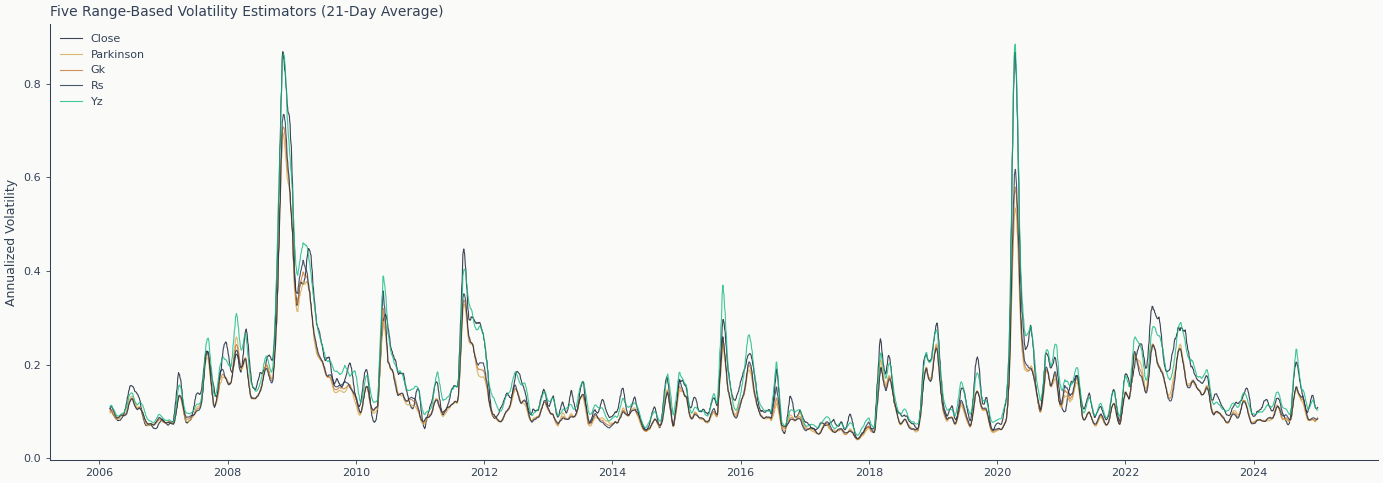

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

rv_pd = spy_rv_ml4t.select(["timestamp"] + rv_cols).drop_nulls().to_pandas().set_index("timestamp")
# Rolling smooth for readability
rv_smooth = rv_pd.rolling(21).mean()

for col in rv_cols:
    label = col.replace("rv_", "").replace("_", "-").title()
    ax.plot(rv_smooth.index, rv_smooth[col], linewidth=0.8, alpha=0.8, label=label)

ax.set_title("Five Range-Based Volatility Estimators (21-Day Average)")
ax.set_ylabel("Annualized Volatility")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation**: Yang-Zhang and Rogers-Satchell are the most efficient
estimators because they account for overnight gaps and drift, respectively.
Close-to-close is the noisiest. The choice of estimator matters most when
data has frequent overnight gaps or when the underlying has non-zero drift.

### Build HAR Regressors

The HAR model uses three horizons of averaged RV as predictors:
- $RV^{(d)}_t$: daily (1-day) — captures intraday trader behavior
- $RV^{(w)}_t$: weekly average (5-day) — captures medium-term investors
- $RV^{(m)}_t$: monthly average (22-day) — captures institutional rebalancers

In [11]:
def build_har_features(rv_series: pl.Series, timestamps: pl.Series) -> pl.DataFrame:
    """Build HAR regressors from a daily RV series.

    Returns DataFrame with daily, weekly, monthly RV and next-day target.
    """
    df = pl.DataFrame({"timestamp": timestamps, "rv": rv_series})

    har = df.with_columns(
        # Daily RV (lagged 1 day to avoid lookahead)
        rv_daily=pl.col("rv").shift(1),
        # Weekly average: mean of past 5 days (lagged)
        rv_weekly=pl.col("rv").shift(1).rolling_mean(5),
        # Monthly average: mean of past 22 days (lagged)
        rv_monthly=pl.col("rv").shift(1).rolling_mean(22),
        # Target: next-day RV
        rv_target=pl.col("rv"),
    ).drop_nulls()

    return har


# Use Garman-Klass as primary RV estimator
har_data = build_har_features(spy_rv["rv_garman_klass"], spy_rv["timestamp"])
print(f"HAR dataset: {len(har_data):,} observations")
har_data.head(5)

HAR dataset: 4,758 observations


timestamp,rv,rv_daily,rv_weekly,rv_monthly,rv_target
date,f64,f64,f64,f64,f64
2006-02-06,0.0545,0.196979,0.084189,0.078336,0.0545
2006-02-07,0.087305,0.0545,0.087058,0.078048,0.087305
2006-02-08,0.21289,0.087305,0.091138,0.079287,0.21289
2006-02-09,0.101211,0.21289,0.124896,0.084326,0.101211
2006-02-10,0.148424,0.101211,0.130577,0.086524,0.148424


### Estimate HAR via OLS

The HAR model is a simple OLS regression despite its time-series motivation.
The $\beta$ coefficients reveal which horizon dominates current volatility.

In [12]:
def fit_har(df: pl.DataFrame) -> dict:
    """Fit HAR model via OLS and return coefficients + diagnostics."""
    y = df["rv_target"].to_numpy()
    X = np.column_stack(
        [
            np.ones(len(df)),
            df["rv_daily"].to_numpy(),
            df["rv_weekly"].to_numpy(),
            df["rv_monthly"].to_numpy(),
        ]
    )

    # OLS: beta = (X'X)^{-1} X'y
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ beta
    residuals = y - y_hat
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r_squared = 1 - ss_res / ss_tot

    # Standard errors
    n, k = X.shape
    mse = ss_res / (n - k)
    se = np.sqrt(np.diag(mse * np.linalg.inv(X.T @ X)))
    t_stats = beta / se

    return {
        "intercept": beta[0],
        "beta_daily": beta[1],
        "beta_weekly": beta[2],
        "beta_monthly": beta[3],
        "r_squared": r_squared,
        "se": se,
        "t_stats": t_stats,
        "y_hat": y_hat,
        "residuals": residuals,
    }


har_result = fit_har(har_data)

names = ["Intercept", "beta_daily", "beta_weekly", "beta_monthly"]
horizons = ["daily", "weekly", "monthly"]
har_param_rows = []
for i, name in enumerate(names):
    coef = har_result["intercept"] if i == 0 else har_result[f"beta_{horizons[i - 1]}"]
    har_param_rows.append(
        {
            "parameter": name,
            "estimate": coef,
            "std_err": har_result["se"][i],
            "t_stat": har_result["t_stats"][i],
        }
    )
display(pd.DataFrame(har_param_rows))

print(f"R²: {har_result['r_squared']:.4f}")
print(f"Daily contribution: {har_result['beta_daily']:.3f}")
print(f"Weekly contribution: {har_result['beta_weekly']:.3f}")
print(f"Monthly contribution: {har_result['beta_monthly']:.3f}")

,parameter,estimate,std_err,t_stat
0,Intercept,0.009395,0.001702,5.518850
1,beta_daily,0.308356,0.017278,17.847244
2,beta_weekly,0.428317,0.028105,15.239661
3,beta_monthly,0.186129,0.023986,7.760040


R²: 0.6062
Daily contribution: 0.308
Weekly contribution: 0.428
Monthly contribution: 0.186


**Interpretation**: The $\beta$ coefficients decompose the sources of volatility
persistence. A large $\beta_m$ indicates that long-term (institutional) dynamics
dominate; a large $\beta_d$ indicates that short-term shocks drive volatility.
This decomposition is what makes HAR more interpretable than GARCH for
understanding *why* volatility is at its current level.

### HAR vs GARCH Comparison

HAR uses multi-horizon decomposition; GARCH(1,1) uses a single exponential
decay. We compare their out-of-sample forecast accuracy.

In [13]:
from arch import arch_model

# Split into train/test
n = len(har_data)
train_frac = 0.7
n_train = int(n * train_frac)

train_data = har_data.head(n_train)
test_data = har_data.tail(n - n_train)

# HAR forecast on test set (coefficients fit on the training window only)
har_fit = fit_har(train_data)
X_test = np.column_stack(
    [
        np.ones(len(test_data)),
        test_data["rv_daily"].to_numpy(),
        test_data["rv_weekly"].to_numpy(),
        test_data["rv_monthly"].to_numpy(),
    ]
)
har_forecast = X_test @ np.array(
    [
        har_fit["intercept"],
        har_fit["beta_daily"],
        har_fit["beta_weekly"],
        har_fit["beta_monthly"],
    ]
)

In [14]:
# GARCH(1,1) forecast
returns_pct = spy_rv["log_return"].to_numpy() * 100  # Scale for GARCH
returns_pd = pd.Series(
    returns_pct,
    index=pd.DatetimeIndex(spy_rv["timestamp"].to_list()),
    name="returns",
)

garch_model = arch_model(returns_pd.iloc[: n_train + 22], mean="Constant", vol="GARCH", p=1, q=1)
garch_fit = garch_model.fit(disp="off")
garch_cond_vol = garch_fit.conditional_volatility * np.sqrt(252) / 100  # Annualized, unscale

# Align lengths for comparison
test_rv = test_data["rv_target"].to_numpy()
test_dates = test_data["timestamp"].to_list()

# GARCH forecast is from the same period
garch_test = garch_cond_vol.values[-len(test_rv) :]
if len(garch_test) < len(test_rv):
    # Pad with last value if needed
    garch_test = np.pad(garch_test, (len(test_rv) - len(garch_test), 0), mode="edge")
garch_test = garch_test[: len(test_rv)]

# Compute RMSE
rmse_har = np.sqrt(np.mean((har_forecast - test_rv) ** 2))
rmse_garch = np.sqrt(np.mean((garch_test - test_rv) ** 2))
mae_har = np.mean(np.abs(har_forecast - test_rv))
mae_garch = np.mean(np.abs(garch_test - test_rv))

In [15]:
display(
    pd.DataFrame(
        {
            "metric": ["RMSE", "MAE"],
            "HAR": [rmse_har, mae_har],
            "GARCH": [rmse_garch, mae_garch],
        }
    )
)

,metric,HAR,GARCH
0,RMSE,0.061345,0.110654
1,MAE,0.040520,0.074284


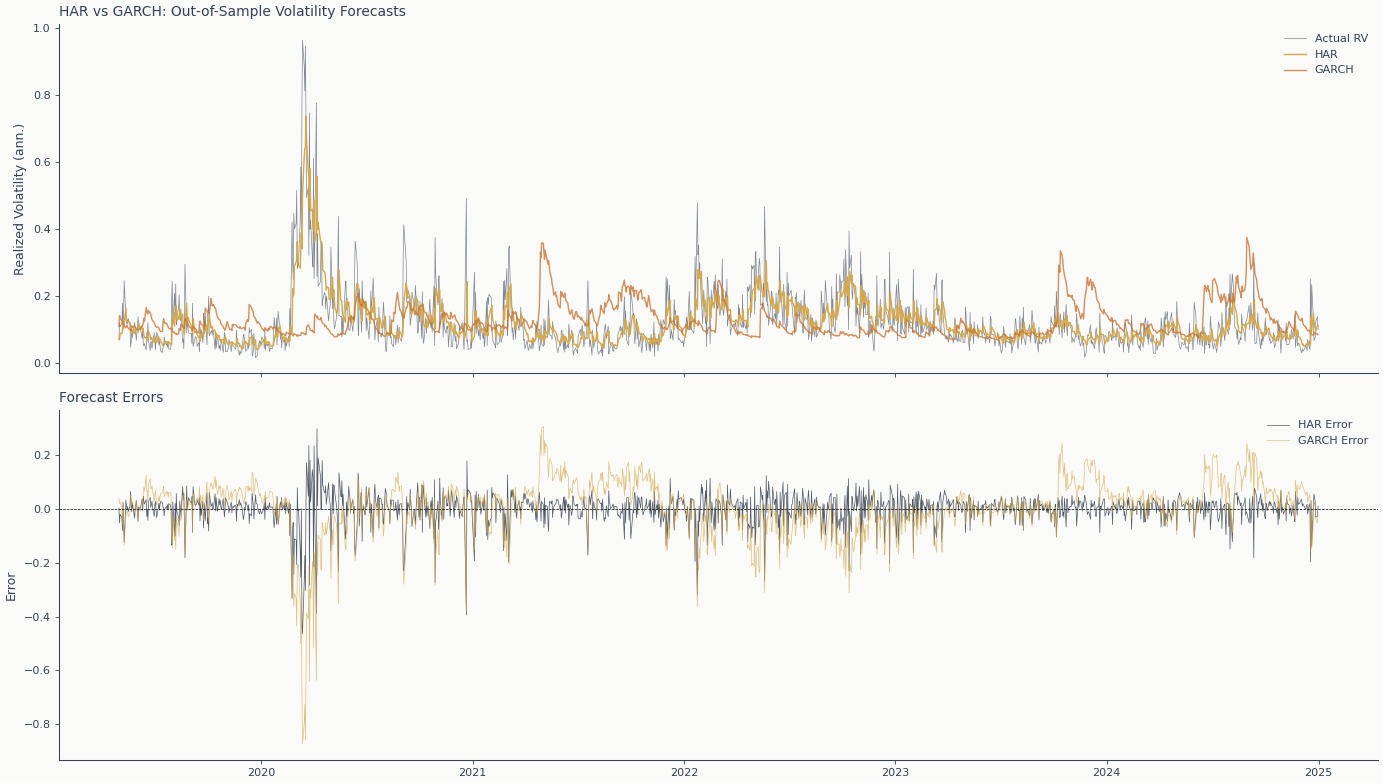

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(test_dates, test_rv, label="Actual RV", alpha=0.5, linewidth=0.5)
ax.plot(test_dates, har_forecast, label="HAR", linewidth=1)
ax.plot(test_dates, garch_test, label="GARCH", linewidth=1, alpha=0.8)
ax.set_title("HAR vs GARCH: Out-of-Sample Volatility Forecasts")
ax.set_ylabel("Realized Volatility (ann.)")
ax.legend()

# Forecast errors
ax = axes[1]
ax.plot(test_dates, har_forecast - test_rv, label="HAR Error", linewidth=0.5, alpha=0.7)
ax.plot(test_dates, garch_test - test_rv, label="GARCH Error", linewidth=0.5, alpha=0.7)
ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
ax.set_title("Forecast Errors")
ax.set_ylabel("Error")
ax.legend()

plt.tight_layout()
plt.show()

### Rolling HAR Estimation

In production, re-estimate HAR coefficients periodically on a rolling window.
The $\beta$ coefficients themselves become slowly varying features that indicate
which horizon dominates current volatility dynamics.

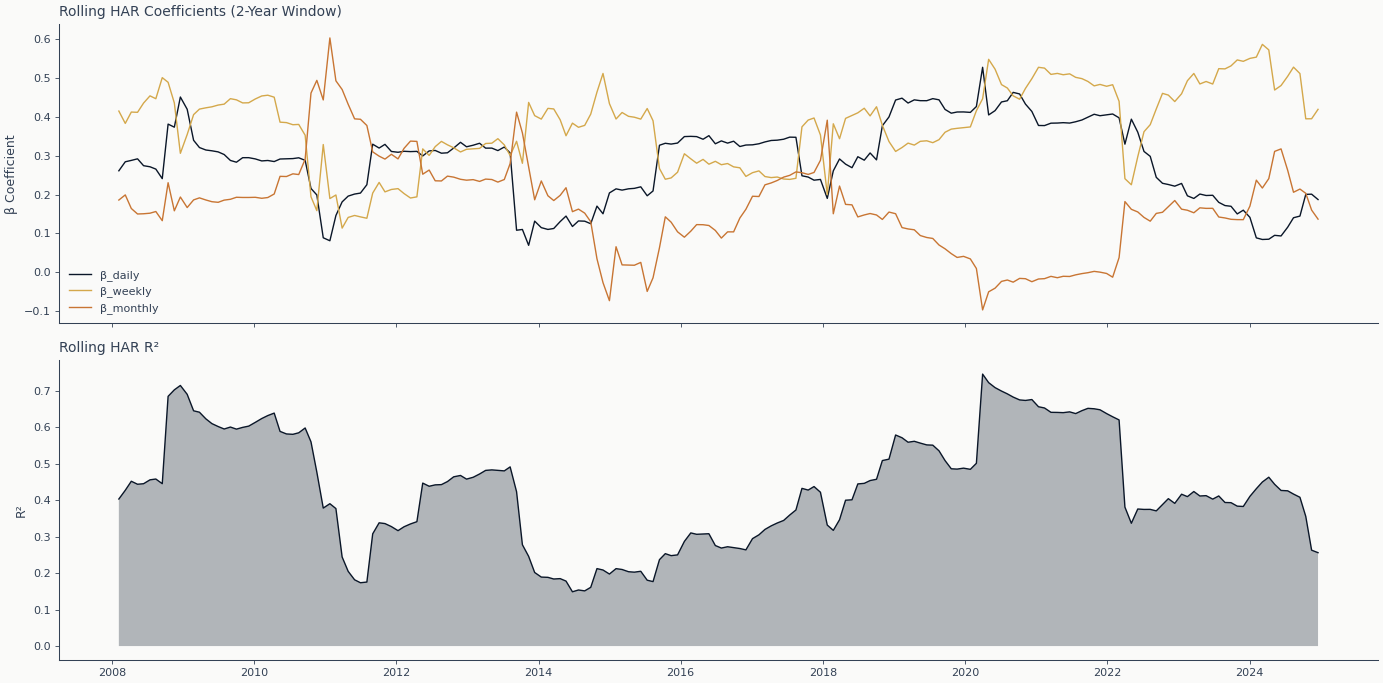

In [17]:
WINDOW = 504  # ~2 years of training data
STEP = 22  # Re-estimate monthly

rolling_betas = []
rolling_dates = []

for start in range(0, len(har_data) - WINDOW, STEP):
    window_data = har_data.slice(start, WINDOW)
    result = fit_har(window_data)
    mid_date = window_data["timestamp"][WINDOW // 2]
    rolling_betas.append(
        {
            "timestamp": window_data["timestamp"][-1],
            "beta_daily": result["beta_daily"],
            "beta_weekly": result["beta_weekly"],
            "beta_monthly": result["beta_monthly"],
            "r_squared": result["r_squared"],
        }
    )

rolling_df = pl.DataFrame(rolling_betas)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

roll_pd = rolling_df.to_pandas().set_index("timestamp")

ax = axes[0]
ax.plot(roll_pd.index, roll_pd["beta_daily"], label="β_daily", linewidth=1)
ax.plot(roll_pd.index, roll_pd["beta_weekly"], label="β_weekly", linewidth=1)
ax.plot(roll_pd.index, roll_pd["beta_monthly"], label="β_monthly", linewidth=1)
ax.set_title("Rolling HAR Coefficients (2-Year Window)")
ax.set_ylabel("β Coefficient")
ax.legend()

ax = axes[1]
ax.fill_between(roll_pd.index, 0, roll_pd["r_squared"], alpha=0.3)
ax.plot(roll_pd.index, roll_pd["r_squared"], linewidth=1)
ax.set_title("Rolling HAR R²")
ax.set_ylabel("R²")

plt.tight_layout()
plt.show()

### Vol Term Structure Feature

The ratio of short-term to long-term RV captures the shape of the volatility
term structure — a feature that indicates whether volatility is expected to
rise (backwardation) or fall (contango).

In [18]:
vol_term = (
    spy_rv.with_columns(
        rv_d=pl.col("rv_garman_klass"),
        rv_w=pl.col("rv_garman_klass").rolling_mean(5),
        rv_m=pl.col("rv_garman_klass").rolling_mean(22),
    )
    .with_columns(
        # Term structure: daily / monthly ratio
        vol_term_structure=pl.col("rv_d") / pl.col("rv_m"),
    )
    .drop_nulls(subset=["vol_term_structure"])
)

vt_pd = vol_term.select(["timestamp", "vol_term_structure"]).to_pandas().set_index("timestamp")

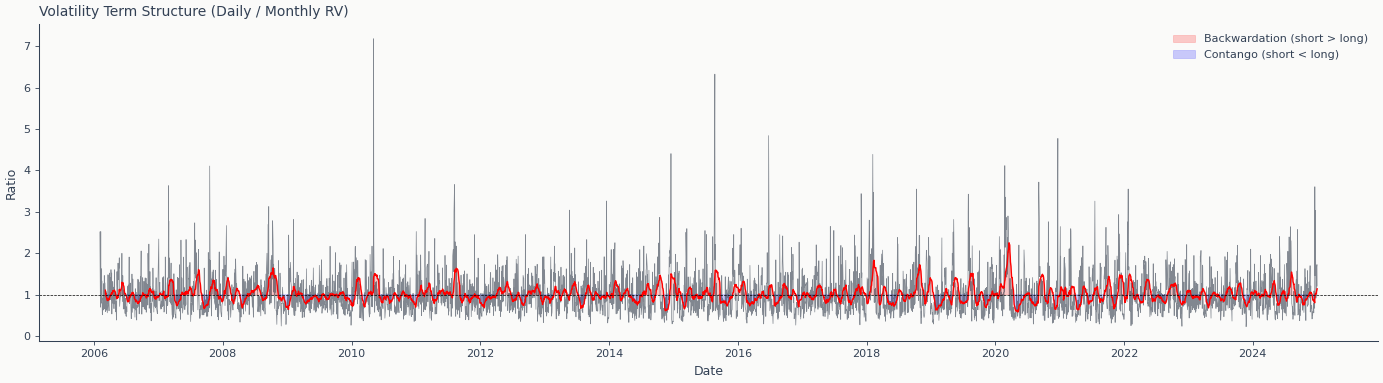

In [19]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(vt_pd.index, vt_pd["vol_term_structure"], linewidth=0.5, alpha=0.5)
ax.plot(vt_pd.index, vt_pd["vol_term_structure"].rolling(21).mean(), linewidth=1, color="red")
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.5)
ax.set_title("Volatility Term Structure (Daily / Monthly RV)")
ax.set_ylabel("Ratio")
ax.set_xlabel("Date")
ax.fill_between(
    vt_pd.index,
    1.0,
    vt_pd["vol_term_structure"].rolling(21).mean(),
    where=vt_pd["vol_term_structure"].rolling(21).mean() > 1.0,
    alpha=0.2,
    color="red",
    label="Backwardation (short > long)",
)
ax.fill_between(
    vt_pd.index,
    1.0,
    vt_pd["vol_term_structure"].rolling(21).mean(),
    where=vt_pd["vol_term_structure"].rolling(21).mean() <= 1.0,
    alpha=0.2,
    color="blue",
    label="Contango (short < long)",
)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Part 2 — Hurst Exponent and Rough Volatility

The Hurst exponent $H \in (0, 1)$ measures the scaling behavior of increments:

- $H < 0.5$: anti-persistent (rough) — increments negatively correlated
- $H = 0.5$: Brownian motion — uncorrelated increments
- $H > 0.5$: persistent (trending) — increments positively correlated

Applied to **returns**, $H$ distinguishes trending from mean-reverting regimes.
Applied to **log-volatility**, $H \approx 0.1$ reveals the "rough volatility"
phenomenon (Gatheral, Jaisson, and Rosenbaum, 2018).

### Rescaled Range (R/S) Analysis

The classic method for estimating $H$. For a time series of length $n$:
1. Divide into windows of size $s$
2. In each window, compute the range $R$ of cumulative deviations from the mean
3. Normalize by the standard deviation $S$
4. The scaling relationship $\mathbb{E}[R/S] \sim s^H$ gives the Hurst exponent

In [20]:
def rescaled_range(series: np.ndarray, min_window: int = 20, max_window: int = None) -> tuple:
    """Compute R/S statistic across multiple window sizes.

    Returns (log_sizes, log_rs, H, intercept) where H is the Hurst exponent.
    """
    n = len(series)
    if max_window is None:
        max_window = n // 4

    # Window sizes: powers of 2 and intermediate values
    sizes = []
    s = min_window
    while s <= max_window:
        sizes.append(s)
        s = int(s * 1.5)  # ~50% increments for good coverage
    sizes = sorted(set(sizes))

    log_sizes = []
    log_rs = []

    for s in sizes:
        n_windows = n // s
        if n_windows < 2:
            continue

        rs_values = []
        for i in range(n_windows):
            window = series[i * s : (i + 1) * s]
            mean = window.mean()
            deviations = np.cumsum(window - mean)
            R = deviations.max() - deviations.min()
            S = window.std(ddof=1)
            if S > 0:
                rs_values.append(R / S)

        if rs_values:
            log_sizes.append(np.log(s))
            log_rs.append(np.log(np.mean(rs_values)))

    log_sizes = np.array(log_sizes)
    log_rs = np.array(log_rs)

    # Linear regression: log(R/S) = H * log(s) + c
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_sizes, log_rs)

    return log_sizes, log_rs, slope, intercept, r_value**2

### Detrended Fluctuation Analysis (DFA)

DFA is more robust than R/S for non-stationary series. It removes local trends
before computing fluctuations:
1. Compute the cumulative sum (profile) of the mean-centered series
2. Divide into windows, fit a local polynomial trend in each
3. Compute the RMS of residuals (fluctuation function $F(s)$)
4. The scaling $F(s) \sim s^\alpha$ gives the DFA exponent $\alpha \approx H$

In [21]:
def dfa(series: np.ndarray, min_window: int = 10, max_window: int = None, order: int = 1) -> tuple:
    """Detrended Fluctuation Analysis.

    Returns (log_sizes, log_F, alpha) where alpha ≈ H.
    """
    n = len(series)
    if max_window is None:
        max_window = n // 4

    # Cumulative sum (profile)
    profile = np.cumsum(series - series.mean())

    sizes = []
    s = min_window
    while s <= max_window:
        sizes.append(s)
        s = int(s * 1.5)
    sizes = sorted(set(sizes))

    log_sizes = []
    log_F = []

    for s in sizes:
        n_windows = n // s
        if n_windows < 2:
            continue

        fluctuations = []
        for i in range(n_windows):
            segment = profile[i * s : (i + 1) * s]
            x = np.arange(s)
            # Fit polynomial trend
            coeffs = np.polyfit(x, segment, order)
            trend = np.polyval(coeffs, x)
            residual = segment - trend
            fluctuations.append(np.sqrt(np.mean(residual**2)))

        if fluctuations:
            log_sizes.append(np.log(s))
            log_F.append(np.log(np.mean(fluctuations)))

    log_sizes = np.array(log_sizes)
    log_F = np.array(log_F)

    slope, intercept, r_value, p_value, std_err = stats.linregress(log_sizes, log_F)

    return log_sizes, log_F, slope, intercept, r_value**2

### Hurst Exponent on Returns vs Log-Volatility

We compute $H$ on two series to demonstrate different behaviors:
- **Returns**: typically $H \approx 0.5$ (near random walk), with deviations
  indicating trending ($H > 0.5$) or mean-reverting ($H < 0.5$) regimes
- **Log-volatility**: typically $H \approx 0.1$ (rough), meaning volatility
  spikes are bursty — they arrive suddenly and decay quickly

In [22]:
returns_np = spy_rv["log_return"].to_numpy()
# Log-volatility from Garman-Klass — use increments for roughness
log_vol_level = np.log(spy_rv["rv_garman_klass"].to_numpy().clip(min=1e-10))
log_vol_incr = np.diff(log_vol_level)  # Increments of log-vol

# R/S analysis on returns
rs_sizes_ret, rs_rs_ret, H_rs_ret, _, r2_rs_ret = rescaled_range(returns_np)
# R/S on log-vol increments (roughness)
rs_sizes_vol, rs_rs_vol, H_rs_vol, _, r2_rs_vol = rescaled_range(log_vol_incr)

# DFA on returns
dfa_sizes_ret, dfa_F_ret, H_dfa_ret, _, r2_dfa_ret = dfa(returns_np)
# DFA on log-vol increments
dfa_sizes_vol, dfa_F_vol, H_dfa_vol, _, r2_dfa_vol = dfa(log_vol_incr)

display(
    pd.DataFrame(
        [
            {
                "series": "Returns",
                "H_RS": H_rs_ret,
                "R²_RS": r2_rs_ret,
                "H_DFA": H_dfa_ret,
                "R²_DFA": r2_dfa_ret,
            },
            {
                "series": "Log-Vol Increments",
                "H_RS": H_rs_vol,
                "R²_RS": r2_rs_vol,
                "H_DFA": H_dfa_vol,
                "R²_DFA": r2_dfa_vol,
            },
        ]
    )
)
print("Returns H ≈ 0.5 confirms near-random-walk behavior.")
print("Log-vol increments H < 0.5 confirms rough volatility (anti-persistent increments).")

,series,H_RS,R²_RS,H_DFA,R²_DFA
0,Returns,0.529575,0.998221,0.504977,0.995419
1,Log-Vol Increments,0.233586,0.990506,0.122943,0.987224


Returns H ≈ 0.5 confirms near-random-walk behavior.
Log-vol increments H < 0.5 confirms rough volatility (anti-persistent increments).


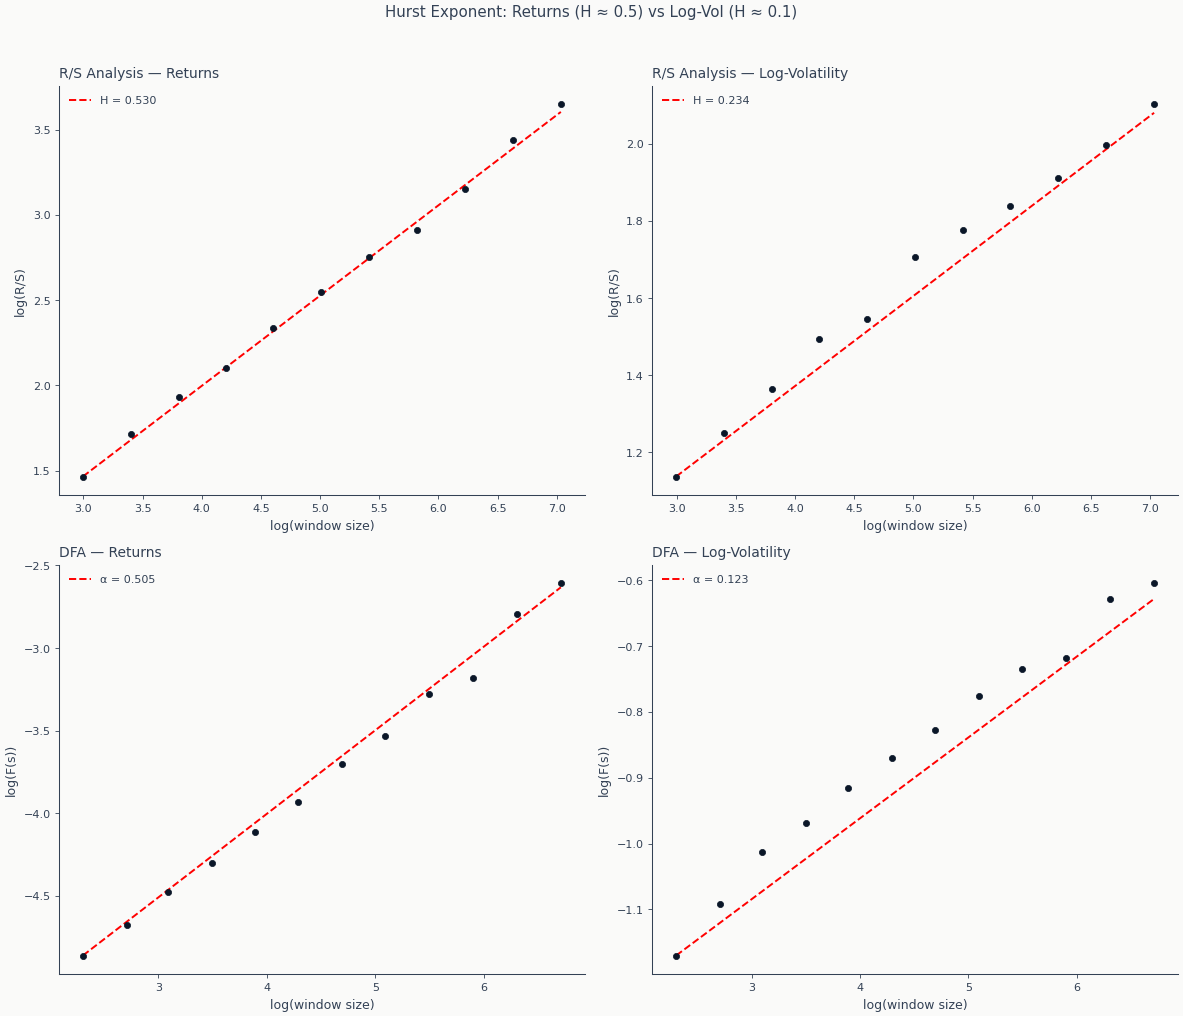

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# R/S: Returns
ax = axes[0, 0]
ax.scatter(rs_sizes_ret, rs_rs_ret, s=20, zorder=5)
ax.plot(
    rs_sizes_ret,
    H_rs_ret * rs_sizes_ret + (rs_rs_ret[0] - H_rs_ret * rs_sizes_ret[0]),
    "r--",
    label=f"H = {H_rs_ret:.3f}",
)
ax.set_title("R/S Analysis — Returns")
ax.set_xlabel("log(window size)")
ax.set_ylabel("log(R/S)")
ax.legend()

# R/S: Log-Volatility
ax = axes[0, 1]
ax.scatter(rs_sizes_vol, rs_rs_vol, s=20, zorder=5)
ax.plot(
    rs_sizes_vol,
    H_rs_vol * rs_sizes_vol + (rs_rs_vol[0] - H_rs_vol * rs_sizes_vol[0]),
    "r--",
    label=f"H = {H_rs_vol:.3f}",
)
ax.set_title("R/S Analysis — Log-Volatility")
ax.set_xlabel("log(window size)")
ax.set_ylabel("log(R/S)")
ax.legend()

# DFA: Returns
ax = axes[1, 0]
ax.scatter(dfa_sizes_ret, dfa_F_ret, s=20, zorder=5)
ax.plot(
    dfa_sizes_ret,
    H_dfa_ret * dfa_sizes_ret + (dfa_F_ret[0] - H_dfa_ret * dfa_sizes_ret[0]),
    "r--",
    label=f"α = {H_dfa_ret:.3f}",
)
ax.set_title("DFA — Returns")
ax.set_xlabel("log(window size)")
ax.set_ylabel("log(F(s))")
ax.legend()

# DFA: Log-Volatility
ax = axes[1, 1]
ax.scatter(dfa_sizes_vol, dfa_F_vol, s=20, zorder=5)
ax.plot(
    dfa_sizes_vol,
    H_dfa_vol * dfa_sizes_vol + (dfa_F_vol[0] - H_dfa_vol * dfa_sizes_vol[0]),
    "r--",
    label=f"α = {H_dfa_vol:.3f}",
)
ax.set_title("DFA — Log-Volatility")
ax.set_xlabel("log(window size)")
ax.set_ylabel("log(F(s))")
ax.legend()

plt.suptitle("Hurst Exponent: Returns (H ≈ 0.5) vs Log-Vol (H ≈ 0.1)", y=1.02)
plt.tight_layout()
plt.show()

### Rolling Hurst Exponent

The Hurst exponent varies over time. Computing it on 252-day rolling windows
produces a slowly varying feature that indicates regime shifts:
- **Returns H > 0.5**: trending regime (momentum strategies favored)
- **Returns H < 0.5**: mean-reverting regime (reversal strategies favored)
- **Log-vol H dropping**: increasing roughness, vol spikes decaying faster

In [24]:
HURST_WINDOW = 252
HURST_STEP = 5  # Compute every 5 days to reduce cost

rolling_hurst = []

for end in range(HURST_WINDOW, len(returns_np), HURST_STEP):
    window_ret = returns_np[end - HURST_WINDOW : end]
    window_vol = log_vol_incr[max(0, end - HURST_WINDOW - 1) : end - 1]

    # DFA is more robust than R/S for shorter windows
    _, _, h_ret, _, _ = dfa(window_ret, min_window=10, max_window=HURST_WINDOW // 4)
    _, _, h_vol, _, _ = dfa(window_vol, min_window=10, max_window=HURST_WINDOW // 4)

    rolling_hurst.append(
        {
            "timestamp": spy_rv["timestamp"][end],
            "hurst_returns": h_ret,
            "roughness_h": h_vol,
        }
    )

hurst_df = pl.DataFrame(rolling_hurst)
hurst_pd = hurst_df.to_pandas().set_index("timestamp")

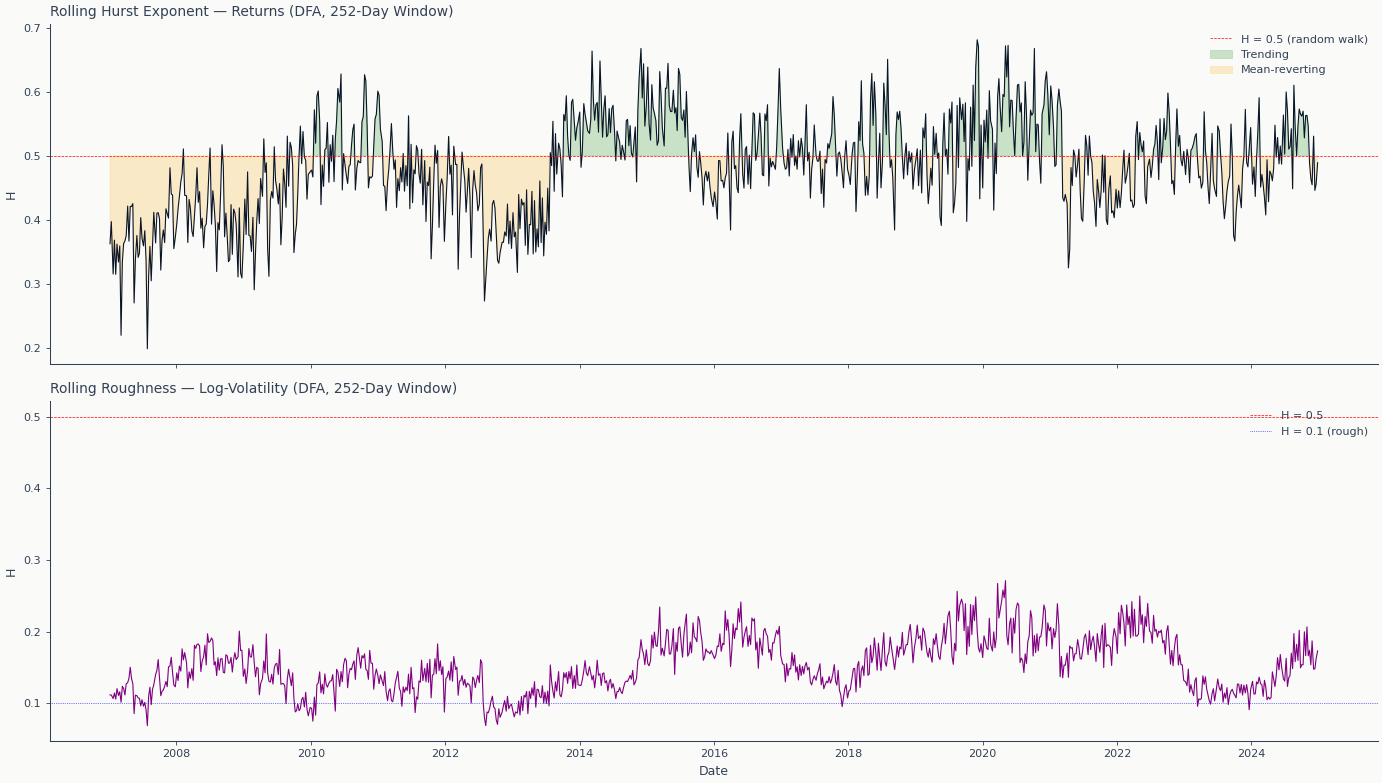

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(hurst_pd.index, hurst_pd["hurst_returns"], linewidth=0.8)
ax.axhline(0.5, color="red", linestyle="--", linewidth=0.5, label="H = 0.5 (random walk)")
ax.fill_between(
    hurst_pd.index,
    0.5,
    hurst_pd["hurst_returns"],
    where=hurst_pd["hurst_returns"] > 0.5,
    alpha=0.2,
    color="green",
    label="Trending",
)
ax.fill_between(
    hurst_pd.index,
    0.5,
    hurst_pd["hurst_returns"],
    where=hurst_pd["hurst_returns"] <= 0.5,
    alpha=0.2,
    color="orange",
    label="Mean-reverting",
)
ax.set_title("Rolling Hurst Exponent — Returns (DFA, 252-Day Window)")
ax.set_ylabel("H")
ax.legend(loc="upper right")

ax = axes[1]
ax.plot(hurst_pd.index, hurst_pd["roughness_h"], linewidth=0.8, color="purple")
ax.axhline(0.5, color="red", linestyle="--", linewidth=0.5, label="H = 0.5")
ax.axhline(0.1, color="blue", linestyle=":", linewidth=0.5, label="H = 0.1 (rough)")
ax.set_title("Rolling Roughness — Log-Volatility (DFA, 252-Day Window)")
ax.set_ylabel("H")
ax.set_xlabel("Date")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

**Interpretation**: The returns Hurst exponent fluctuates around 0.5, with
sustained departures indicating regime changes. The log-volatility Hurst stays
well below 0.5, confirming the rough-volatility phenomenon empirically. When
roughness $H$ drops further (toward 0.05–0.1), volatility spikes are more
bursty and GARCH-based forecasts — which assume smooth dynamics — may
underestimate the speed of vol decay after a spike.

### ml4t-engineer: Hurst Exponent as a Polars Expression

The manual R/S and DFA implementations above total ~100 lines of NumPy code.
For production pipelines, `hurst_exponent()` computes a rolling Hurst estimate
as a single Polars expression — suitable for `with_columns()` across
many symbols.

In [26]:
spy_hurst = spy.with_columns(
    hurst=hurst_exponent("close", period=252),
)

hurst_vals = spy_hurst["hurst"].drop_nulls()
print(
    f"ml4t-engineer Hurst: mean={hurst_vals.mean():.3f}, "
    f"std={hurst_vals.std():.3f}, "
    f"min={hurst_vals.min():.3f}, max={hurst_vals.max():.3f}"
)

ml4t-engineer Hurst: mean=0.598, std=0.041, min=0.488, max=0.713


**Note**: The library call above applies R/S analysis to **close prices**,
while the manual DFA computation earlier used **returns** and **log-volatility
increments**. These are different inputs and will produce different Hurst
estimates — the close-price version measures persistence in levels, while the
returns version measures persistence in changes. Use the manual implementation
to understand the methodology and to apply it to the appropriate series; use
the library expression for multi-symbol pipelines when the R/S-on-prices
approximation is acceptable.

## Feature Catalog: HAR and Hurst Features

| Feature | Source | Computation | Update |
|---------|--------|-------------|--------|
| `rv_daily` | Range-based | Garman-Klass daily | Daily |
| `rv_weekly` | Range-based | 5-day average | Daily |
| `rv_monthly` | Range-based | 22-day average | Daily |
| `daily_contribution` | HAR | β_d coefficient | Weekly/monthly |
| `monthly_contribution` | HAR | β_m coefficient | Weekly/monthly |
| `vol_term_structure` | RV ratios | rv_daily / rv_monthly | Daily |
| `hurst_exponent` | DFA on returns | Rolling 252-day | Weekly |
| `roughness_h` | DFA on log-vol | Rolling 252-day | Weekly |

## Multi-Asset Application

Compute HAR features and Hurst exponents across multiple ETFs to show
cross-sectional variation in volatility dynamics.

In [27]:
def compute_features_for_symbol(symbol: str, etf_df: pl.DataFrame) -> dict | None:
    """Compute HAR and Hurst features for a single symbol."""
    sym_data = etf_df.filter(pl.col("symbol") == symbol).sort("timestamp")
    if len(sym_data) < 600:
        return None

    # Range-based RV
    sym_rv = compute_range_rv(sym_data).drop_nulls(subset=["log_return"])
    if len(sym_rv) < 300:
        return None

    # HAR estimation
    har = build_har_features(sym_rv["rv_garman_klass"], sym_rv["timestamp"])
    if len(har) < 100:
        return None

    try:
        har_fit = fit_har(har)
    except Exception:
        return None

    # Full-sample Hurst
    returns = sym_rv["log_return"].to_numpy()
    log_v = np.log(sym_rv["rv_garman_klass"].to_numpy().clip(min=1e-10))
    log_v_incr = np.diff(log_v)

    try:
        _, _, h_ret, _, _ = dfa(returns, min_window=10)
        _, _, h_vol, _, _ = dfa(log_v_incr, min_window=10)
    except Exception:
        h_ret, h_vol = np.nan, np.nan

    return {
        "symbol": symbol,
        "n_obs": len(sym_rv),
        "beta_daily": har_fit["beta_daily"],
        "beta_weekly": har_fit["beta_weekly"],
        "beta_monthly": har_fit["beta_monthly"],
        "har_r2": har_fit["r_squared"],
        "hurst_returns": h_ret,
        "roughness_h": h_vol,
    }


# Process all symbols
etf_filtered = etf_data.filter((pl.col("timestamp") >= START) & (pl.col("timestamp") <= END)).sort(
    "timestamp"
)

symbols = etf_filtered["symbol"].unique().sort().to_list()

results = []
for sym in symbols:
    r = compute_features_for_symbol(sym, etf_filtered)
    if r is not None:
        results.append(r)

multi_df = pl.DataFrame(results)
print(f"\nComputed features for {len(multi_df)} / {len(symbols)} symbols")


Computed features for 100 / 100 symbols


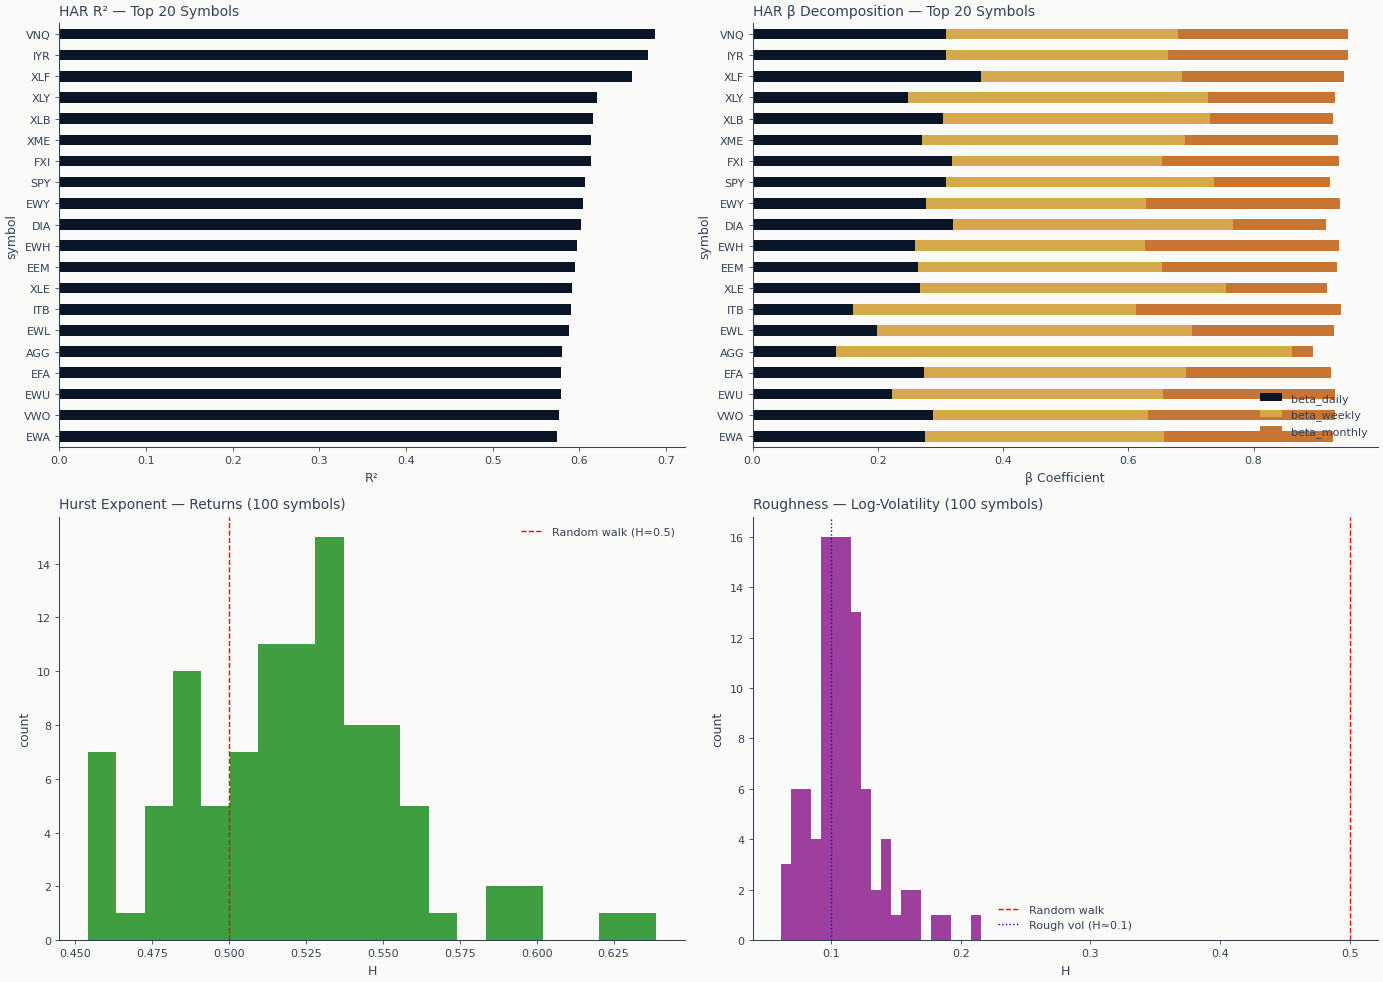

In [28]:
# Subsample to top-N by HAR R² for readability — with ~100 ETFs the barh y-ticks
# collide into a black smear; the cross-sectional pattern is preserved by taking
# the strongest and weakest tails.
TOP_N = 20
multi_pd_full = multi_df.to_pandas().set_index("symbol")
top_by_r2 = multi_pd_full.nlargest(TOP_N, "har_r2").sort_values("har_r2")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# HAR R²
ax = axes[0, 0]
top_by_r2["har_r2"].plot.barh(ax=ax)
ax.set_title(f"HAR R² — Top {TOP_N} Symbols")
ax.set_xlabel("R²")

# Beta decomposition (same subset, same order)
ax = axes[0, 1]
top_by_r2[["beta_daily", "beta_weekly", "beta_monthly"]].plot.barh(stacked=True, ax=ax)
ax.set_title(f"HAR β Decomposition — Top {TOP_N} Symbols")
ax.set_xlabel("β Coefficient")
ax.legend(loc="lower right")

# Hurst on returns — show full distribution as histogram (universe view)
ax = axes[1, 0]
ax.hist(multi_pd_full["hurst_returns"].dropna(), bins=20, color="green", alpha=0.75)
ax.axvline(0.5, color="red", linestyle="--", linewidth=1.0, label="Random walk (H=0.5)")
ax.set_title(f"Hurst Exponent — Returns ({len(multi_pd_full)} symbols)")
ax.set_xlabel("H")
ax.set_ylabel("count")
ax.legend()

# Roughness on log-vol — distribution view
ax = axes[1, 1]
ax.hist(multi_pd_full["roughness_h"].dropna(), bins=20, color="purple", alpha=0.75)
ax.axvline(0.5, color="red", linestyle="--", linewidth=1.0, label="Random walk")
ax.axvline(0.1, color="blue", linestyle=":", linewidth=1.0, label="Rough vol (H≈0.1)")
ax.set_title(f"Roughness — Log-Volatility ({len(multi_pd_full)} symbols)")
ax.set_xlabel("H")
ax.set_ylabel("count")
ax.legend()

plt.tight_layout()
plt.show()

## Save HAR and Hurst Features for Downstream Chapters

Multi-asset HAR coefficients and Hurst exponents are consumed by:
- Chapter 12: Gradient boosting uses volatility regime features
- Chapter 18: Position sizing depends on volatility horizon decomposition

In [29]:
from utils.paths import REPO_ROOT, get_case_study_dir

MODEL_DIR = get_case_study_dir("etfs") / "models" / "time_series"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

output_path = MODEL_DIR / "har_hurst_features.parquet"
multi_df.write_parquet(output_path)

print(f"Saved HAR/Hurst features to {output_path}")
print(f"  Shape: {multi_df.shape}")
print(f"  Symbols: {len(multi_df)}")

Saved HAR/Hurst features to case_studies/etfs/models/time_series/har_hurst_features.parquet
  Shape: (100, 8)
  Symbols: 100


## Key Takeaways

1. **HAR decomposes volatility by horizon**: daily, weekly, monthly components
   reveal which timescale drives current conditions — more interpretable than
   GARCH's single exponential decay
2. **Range-based estimators** (Parkinson, Garman-Klass, Rogers-Satchell,
   Yang-Zhang) extract more variance information from OHLC data than
   close-to-close returns alone
3. **Hurst exponent on returns** distinguishes trending ($H > 0.5$) from
   mean-reverting ($H < 0.5$) regimes — a slowly varying feature for strategy
   selection
4. **Rough volatility** ($H \approx 0.1$ on log-vol) means volatility spikes
   are bursty and decay faster than smooth-volatility models predict
5. **Rolling estimation** of both HAR $\beta$s and Hurst produces time-varying
   features; re-estimate weekly to avoid noise
6. **ml4t-engineer** provides all five range-based estimators and
   `hurst_exponent()` as Polars expressions — use the manual implementations
   to learn, then the library for multi-symbol pipelines

**Previous**: `08_garch_volatility` for GARCH/EGARCH conditional volatility features.
**Next**: `10_uncertainty_features` for Bayesian uncertainty quantification.